In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib import rcParams
from scipy.signal import butter, filtfilt, find_peaks

# 한글 폰트 설정 (선택사항)
rcParams['font.sans-serif'] = ['DejaVu Sans']
rcParams['axes.unicode_minus'] = False

In [137]:
# [1] 피험자 선택 
SUBJECT = 'Sub30'  

print(f"분석 대상 피험자: {SUBJECT}")

분석 대상 피험자: Sub30


In [138]:
# ============================================================================
# [2] CATSA BVP 원본에서 HR / RMSSD 직접 계산 + 공통 QC
# ============================================================================

DATA_ROOT = Path('/home/binghin2/Myproject/Dataset/CATSA')
OUTPUT_DIR = Path('/home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tasks = ['Logic', 'Nback', 'Stroop', 'Sudoku']
all_conditions = ['Baseline'] + tasks
FS = 64  # CATSA BVP 샘플링 레이트(Hz)

# ---------- QC 규칙(모든 피험자 공통 적용) ----------
BVP_ABS_MAX = 1000.0          # 물리적으로 불가능한 메타/이상치 제거
MIN_SIGNAL_SECONDS = 10       # 최소 신호 길이(초)
MIN_SIGNAL_LEN = FS * MIN_SIGNAL_SECONDS
MIN_PEAKS = 4                 # 최소 피크 개수
MIN_VALID_IBI = 3             # 최소 유효 IBI 개수
IBI_MIN_MS = 300.0            # IBI 하한(ms)
IBI_MAX_MS = 2000.0           # IBI 상한(ms)
MIN_VALID_IBI_RATIO = 0.60    # 유효 IBI 비율 하한
PROM_FACTOR = 0.25            # 피크 prominence 계수


def subject_key(name: str) -> int:
    return int(name.replace('Sub', ''))


def load_bvp_series_with_qc(csv_path: Path) -> tuple[np.ndarray, dict]:
    """BVP를 불러오고 물리적으로 불가능한 이상치를 제거한다."""
    series = pd.read_csv(csv_path).squeeze('columns')
    raw = pd.to_numeric(series, errors='coerce').dropna().to_numpy(dtype=float)

    qc = {
        'n_raw': int(raw.size),
        'n_removed_absmax': 0,
        'n_after_clean': 0,
    }

    clean = raw[np.isfinite(raw)]
    before_abs = clean.size
    clean = clean[np.abs(clean) <= BVP_ABS_MAX]
    qc['n_removed_absmax'] = int(before_abs - clean.size)
    qc['n_after_clean'] = int(clean.size)

    return clean, qc


def bandpass_bvp(signal: np.ndarray, fs: int = FS, low: float = 0.7, high: float = 4.0, order: int = 3) -> np.ndarray:
    """심박 대역(약 42~240 BPM)만 통과시키는 Butterworth band-pass."""
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, signal)


def evaluate_condition(csv_path: Path, fs: int = FS) -> dict:
    """단일 Condition(BVP.csv)에 대해 QC + HR/RMSSD 계산."""
    signal, qc = load_bvp_series_with_qc(csv_path)

    reasons = []
    if qc['n_after_clean'] < MIN_SIGNAL_LEN:
        reasons.append(f'short_signal(n={qc["n_after_clean"]})')

    result = {
        'file_path': str(csv_path),
        'n_raw': qc['n_raw'],
        'n_removed_absmax': qc['n_removed_absmax'],
        'n_after_clean': qc['n_after_clean'],
        'n_peaks': 0,
        'n_raw_ibi': 0,
        'n_valid_ibi': 0,
        'valid_ibi_ratio': 0.0,
        'mean_hr': np.nan,
        'rmssd': np.nan,
        'is_valid': False,
        'reason': ''
    }

    if reasons:
        result['reason'] = '; '.join(reasons)
        return result

    try:
        filtered = bandpass_bvp(signal, fs=fs)
        min_distance = int(0.4 * fs)  # 최대 150 BPM 가정
        prom = max(np.std(filtered) * PROM_FACTOR, 1e-6)
        peaks, _ = find_peaks(filtered, distance=min_distance, prominence=prom)

        result['n_peaks'] = int(peaks.size)
        if peaks.size < MIN_PEAKS:
            reasons.append(f'low_peaks(n={peaks.size})')

        raw_ibi = np.diff(peaks) / fs * 1000.0
        result['n_raw_ibi'] = int(raw_ibi.size)

        if raw_ibi.size == 0:
            reasons.append('no_ibi')
            valid_ibi = np.array([], dtype=float)
        else:
            valid_ibi = raw_ibi[(raw_ibi >= IBI_MIN_MS) & (raw_ibi <= IBI_MAX_MS)]

        result['n_valid_ibi'] = int(valid_ibi.size)
        ratio = (valid_ibi.size / raw_ibi.size) if raw_ibi.size > 0 else 0.0
        result['valid_ibi_ratio'] = float(ratio)

        if valid_ibi.size < MIN_VALID_IBI:
            reasons.append(f'low_valid_ibi(n={valid_ibi.size})')
        if ratio < MIN_VALID_IBI_RATIO:
            reasons.append(f'low_valid_ibi_ratio(r={ratio:.3f})')

        if len(reasons) == 0:
            result['mean_hr'] = float(60000.0 / np.mean(valid_ibi))
            result['rmssd'] = float(np.sqrt(np.mean(np.diff(valid_ibi) ** 2)))
            result['is_valid'] = True
            result['reason'] = 'ok'
        else:
            result['reason'] = '; '.join(reasons)

    except Exception as e:
        result['reason'] = f'processing_error({type(e).__name__}: {e})'

    return result


# ---------- 대상 피험자 목록(Sub1~Sub53 중 실제 존재 폴더) ----------
subjects = [f'Sub{i}' for i in range(1, 54) if (DATA_ROOT / f'Sub{i}').exists()]

qc_rows = []
valid_subject_metrics = []
excluded_rows = []

for subj in subjects:
    subj_dir = DATA_ROOT / subj
    cond_results = []

    missing_conds = [c for c in all_conditions if not (subj_dir / c / 'BVP.csv').exists()]
    if missing_conds:
        excluded_rows.append({
            'Subject': subj,
            'Excluded': True,
            'Failed_Conditions': ', '.join(missing_conds),
            'Reasons': 'missing_bvp_file'
        })
        for c in all_conditions:
            qc_rows.append({
                'Subject': subj,
                'Condition': c,
                'file_path': str(subj_dir / c / 'BVP.csv'),
                'n_raw': 0,
                'n_removed_absmax': 0,
                'n_after_clean': 0,
                'n_peaks': 0,
                'n_raw_ibi': 0,
                'n_valid_ibi': 0,
                'valid_ibi_ratio': 0.0,
                'mean_hr': np.nan,
                'rmssd': np.nan,
                'is_valid': False,
                'reason': 'missing_bvp_file'
            })
        continue

    for cond in all_conditions:
        bvp_path = subj_dir / cond / 'BVP.csv'
        res = evaluate_condition(bvp_path, fs=FS)
        res_row = {'Subject': subj, 'Condition': cond, **res}
        qc_rows.append(res_row)
        cond_results.append(res_row)

    fail_rows = [r for r in cond_results if not r['is_valid']]
    if fail_rows:
        excluded_rows.append({
            'Subject': subj,
            'Excluded': True,
            'Failed_Conditions': ', '.join(r['Condition'] for r in fail_rows),
            'Reasons': ' | '.join(f"{r['Condition']}: {r['reason']}" for r in fail_rows)
        })
        continue

    # 모두 통과한 subject만 분석 포함
    for r in cond_results:
        valid_subject_metrics.append({
            'Subject': subj,
            'Condition': r['Condition'],
            'Mean_HR': r['mean_hr'],
            'RMSSD': r['rmssd']
        })

qc_report_df = pd.DataFrame(qc_rows)
metrics_long_df = pd.DataFrame(valid_subject_metrics)
exclusion_df = pd.DataFrame(excluded_rows)

# Delta 계산 (분석 포함 피험자만)
if not metrics_long_df.empty:
    base_df = metrics_long_df[metrics_long_df['Condition'] == 'Baseline'][['Subject', 'Mean_HR', 'RMSSD']].rename(
        columns={'Mean_HR': 'Base_HR', 'RMSSD': 'Base_RMSSD'}
    )
    task_df = metrics_long_df[metrics_long_df['Condition'].isin(tasks)].copy().rename(columns={'Condition': 'Task'})
    delta_long_df = task_df.merge(base_df, on='Subject', how='left')
    delta_long_df['Delta_HR'] = delta_long_df['Mean_HR'] - delta_long_df['Base_HR']
    delta_long_df['Delta_RMSSD'] = delta_long_df['RMSSD'] - delta_long_df['Base_RMSSD']
else:
    delta_long_df = pd.DataFrame(columns=['Subject', 'Task', 'Delta_HR', 'Delta_RMSSD'])

# Subject 선택값과 호환되는 df(개별 플롯용)
if not delta_long_df.empty and SUBJECT in set(delta_long_df['Subject']):
    df = delta_long_df[delta_long_df['Subject'] == SUBJECT][['Task', 'Delta_HR', 'Delta_RMSSD']].reset_index(drop=True)
else:
    df = pd.DataFrame({'Task': tasks, 'Delta_HR': [np.nan]*4, 'Delta_RMSSD': [np.nan]*4})

# 결과 저장(재현성)
qc_report_path = OUTPUT_DIR / 'qc_report_all_subjects.csv'
exclusion_path = OUTPUT_DIR / 'excluded_cases.csv'
delta_path = OUTPUT_DIR / 'delta_all_subjects.csv'

qc_report_df.to_csv(qc_report_path, index=False)
if not exclusion_df.empty:
    exclusion_df.to_csv(exclusion_path, index=False)
else:
    pd.DataFrame(columns=['Subject', 'Excluded', 'Failed_Conditions', 'Reasons']).to_csv(exclusion_path, index=False)
delta_long_df.to_csv(delta_path, index=False)

included_subjects = sorted(delta_long_df['Subject'].unique(), key=subject_key) if not delta_long_df.empty else []
excluded_subjects = sorted(set(subjects) - set(included_subjects), key=subject_key)

print('=== QC 적용 결과 요약 ===')
print(f'- 전체 대상 피험자: {len(subjects)}명')
print(f'- 분석 포함: {len(included_subjects)}명')
print(f'- 분석 제외: {len(excluded_subjects)}명')

print('\n=== 산출 파일 ===')
print(f'- QC 리포트: {qc_report_path}')
print(f'- 제외 케이스: {exclusion_path}')
print(f'- Delta 전체: {delta_path}')

if excluded_subjects:
    print('\n=== 제외 피험자 목록 ===')
    print(excluded_subjects)

if SUBJECT in included_subjects:
    print(f'\n{SUBJECT}는 QC 통과하여 시각화 대상입니다.')
else:
    print(f'\n{SUBJECT}는 QC 미통과 또는 데이터 누락으로 시각화에서 제외됩니다.')

=== QC 적용 결과 요약 ===
- 전체 대상 피험자: 50명
- 분석 포함: 50명
- 분석 제외: 0명

=== 산출 파일 ===
- QC 리포트: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs/qc_report_all_subjects.csv
- 제외 케이스: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs/excluded_cases.csv
- Delta 전체: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs/delta_all_subjects.csv

Sub30는 QC 통과하여 시각화 대상입니다.


In [139]:
# ============================================================================
# [3] Sub1~Sub53 전원 플롯 생성 (PPT용 PNG 저장)
# ============================================================================

SHOW_ALL_FIGURES = False  # True로 바꾸면 노트북에 모든 피험자 플롯을 순서대로 출력


def plot_subject_delta(subject: str, sub_df: pd.DataFrame, save_path: Path, show_plot: bool = False) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    palette_hr = sns.color_palette('Blues', n_colors=len(tasks))
    palette_rmssd = sns.color_palette('Oranges', n_colors=len(tasks))

    # 왼쪽: Delta HR
    ax1 = axes[0]
    ax1.bar(sub_df['Task'], sub_df['Delta_HR'], color=palette_hr, edgecolor='black', linewidth=1.2)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax1.set_xlabel('Task', fontsize=12, fontweight='bold')
    ax1.set_ylabel('$\\Delta$ Mean HR (BPM)', fontsize=12, fontweight='bold')
    ax1.set_title('Main Metric 1: $\\Delta$ Mean HR\\n(Sensory Intake)', fontsize=13, fontweight='bold', pad=12)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')

    hr_min, hr_max = sub_df['Delta_HR'].min(), sub_df['Delta_HR'].max()
    hr_span = max(hr_max - hr_min, 1.0)
    hr_pad = 0.18 * hr_span
    ax1.set_ylim(hr_min - hr_pad, hr_max + hr_pad)

    for i, val in enumerate(sub_df['Delta_HR']):
        offset = 0.08 * hr_span
        y_text = val + offset if val >= 0 else val - offset
        ax1.text(i, y_text, f'{val:.1f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10, fontweight='bold', clip_on=False)

    # 오른쪽: Delta RMSSD
    ax2 = axes[1]
    ax2.bar(sub_df['Task'], sub_df['Delta_RMSSD'], color=palette_rmssd, edgecolor='black', linewidth=1.2)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax2.set_xlabel('Task', fontsize=12, fontweight='bold')
    ax2.set_ylabel('$\\Delta$ RMSSD (ms)', fontsize=12, fontweight='bold')
    ax2.set_title('Main Metric 2: $\\Delta$ RMSSD\\n(Autonomic Flexibility)', fontsize=13, fontweight='bold', pad=12)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')

    rm_min, rm_max = sub_df['Delta_RMSSD'].min(), sub_df['Delta_RMSSD'].max()
    rm_span = max(rm_max - rm_min, 0.1)
    rm_pad = 0.18 * rm_span
    ax2.set_ylim(rm_min - rm_pad, rm_max + rm_pad)

    for i, val in enumerate(sub_df['Delta_RMSSD']):
        offset = 0.08 * rm_span
        y_text = val + offset if val >= 0 else val - offset
        ax2.text(i, y_text, f'{val:.2f}', ha='center', va='bottom' if val >= 0 else 'top', fontsize=10, fontweight='bold', clip_on=False)

    plt.suptitle(f'{subject} - Biosignal Changes by Task (Baseline)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches='tight')

    if show_plot:
        plt.show()
    else:
        plt.close(fig)


if len(included_subjects) == 0:
    print('QC를 통과한 피험자가 없어 플롯을 생성하지 못했습니다.')
else:
    image_rows = []
    for subject in included_subjects:
        sub_df = delta_long_df[delta_long_df['Subject'] == subject][['Task', 'Delta_HR', 'Delta_RMSSD']].reset_index(drop=True)
        save_path = OUTPUT_DIR / f'{subject}_delta_plot.png'
        plot_subject_delta(subject, sub_df, save_path, show_plot=SHOW_ALL_FIGURES)
        image_rows.append({'Subject': subject, 'ImagePath': str(save_path)})

    image_manifest_df = pd.DataFrame(image_rows)
    manifest_path = OUTPUT_DIR / 'image_manifest.csv'
    image_manifest_df.to_csv(manifest_path, index=False)

    print('=== 플롯 생성 완료 ===')
    print(f'- 생성 이미지 수: {len(image_manifest_df)}')
    print(f'- 이미지 폴더: {OUTPUT_DIR}')
    print(f'- 매니페스트: {manifest_path}')
    print('\nPPT에는 image_manifest.csv 순서대로 붙이면 됩니다.')

=== 플롯 생성 완료 ===
- 생성 이미지 수: 50
- 이미지 폴더: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs
- 매니페스트: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs/image_manifest.csv

PPT에는 image_manifest.csv 순서대로 붙이면 됩니다.


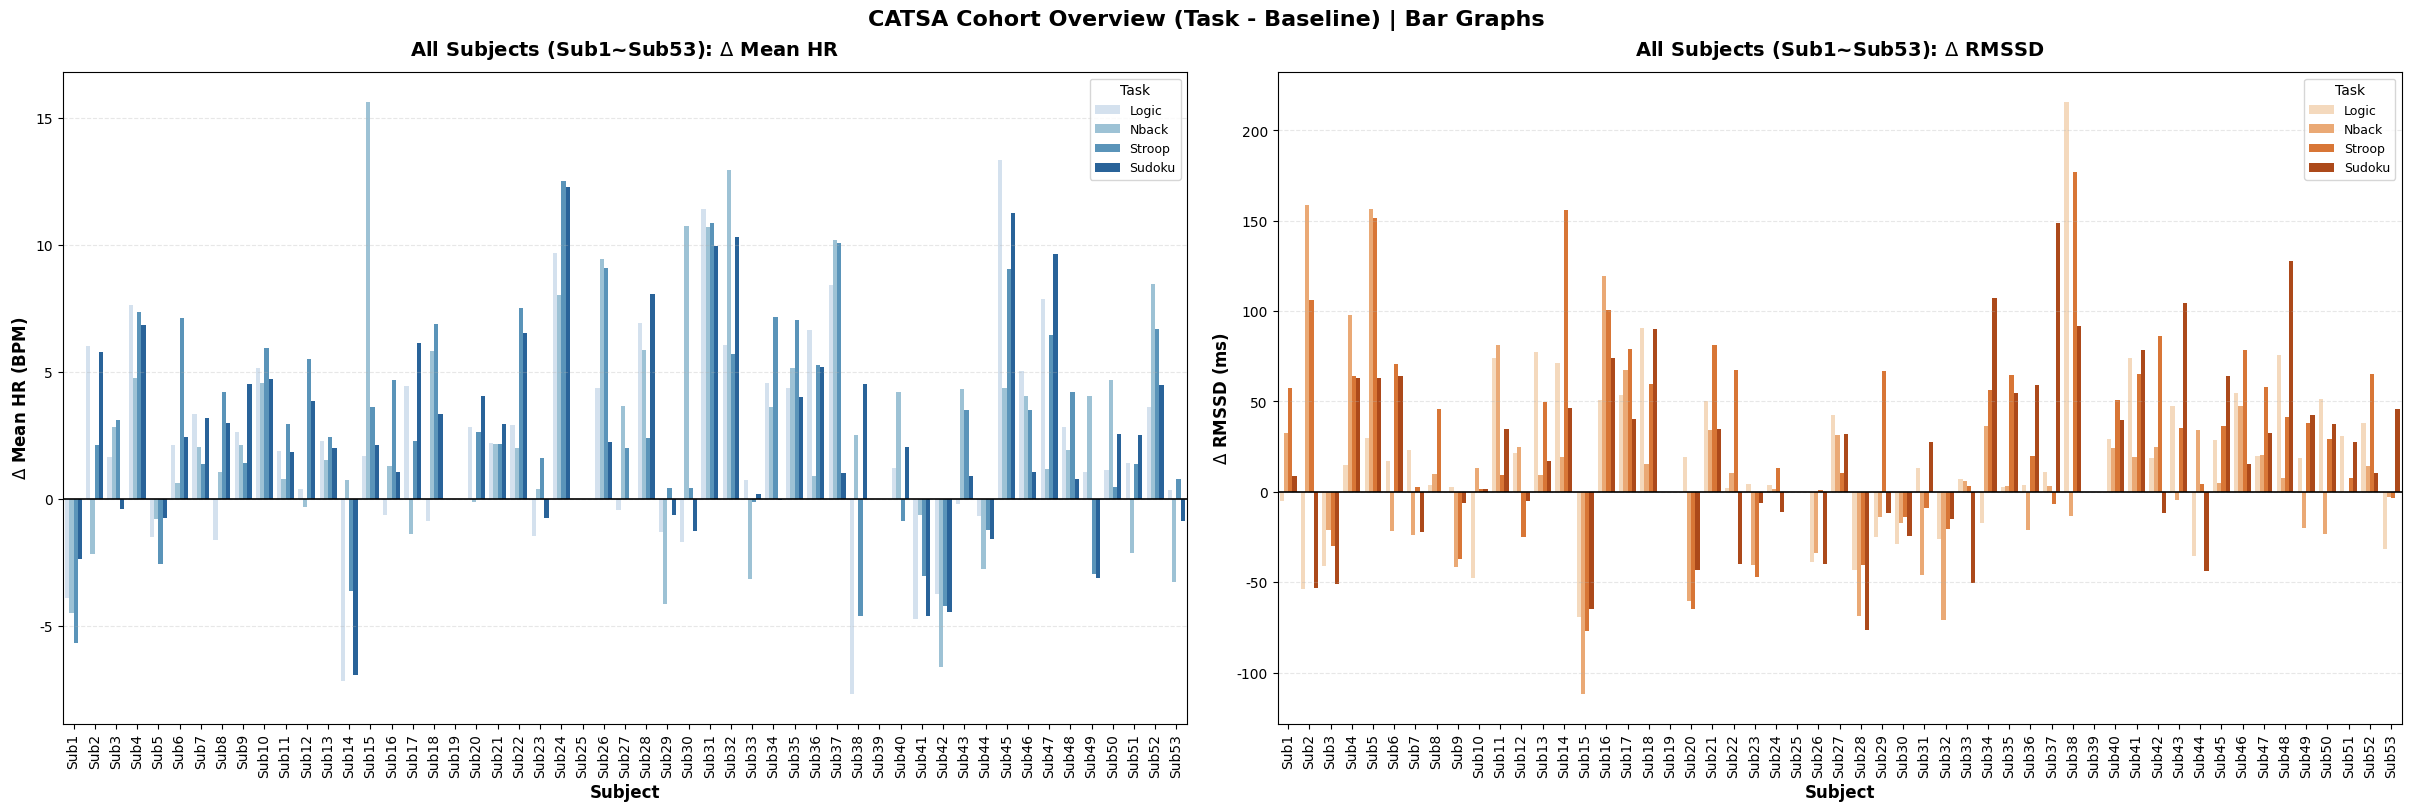

저장 완료: /home/binghin2/Myproject/Research/CATSA/Data_Analysis/Delta_HR_outputs/all_subjects_delta_barplots.png


In [141]:
# ============================================================================
# [4] 전체 피험자(Sub1~Sub53) 한 번에 보기: Bar Graph 2개
# ============================================================================

subjects_all = [f'Sub{i}' for i in range(1, 54)]

# Sub1~Sub53 전체 격자(누락 피험자는 NaN으로 남김)
full_grid = pd.MultiIndex.from_product([subjects_all, tasks], names=['Subject', 'Task']).to_frame(index=False)
plot_long = full_grid.merge(
    delta_long_df[['Subject', 'Task', 'Delta_HR', 'Delta_RMSSD']],
    on=['Subject', 'Task'],
    how='left'
)

# Subject 순서 고정
plot_long['Subject'] = pd.Categorical(plot_long['Subject'], categories=subjects_all, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 8), constrained_layout=True)

# 좌측: Delta Mean HR barplot
sns.barplot(
    data=plot_long,
    x='Subject',
    y='Delta_HR',
    hue='Task',
    hue_order=tasks,
    palette='Blues',
    errorbar=None,
    ax=axes[0]
)
axes[0].axhline(0, color='black', linewidth=1.2)
axes[0].set_title('All Subjects (Sub1~Sub53): $\\Delta$ Mean HR', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Subject', fontsize=12, fontweight='bold')
axes[0].set_ylabel('$\\Delta$ Mean HR (BPM)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].legend(title='Task', loc='upper right', fontsize=9)

# 우측: Delta RMSSD barplot
sns.barplot(
    data=plot_long,
    x='Subject',
    y='Delta_RMSSD',
    hue='Task',
    hue_order=tasks,
    palette='Oranges',
    errorbar=None,
    ax=axes[1]
)
axes[1].axhline(0, color='black', linewidth=1.2)
axes[1].set_title('All Subjects (Sub1~Sub53): $\\Delta$ RMSSD', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Subject', fontsize=12, fontweight='bold')
axes[1].set_ylabel('$\\Delta$ RMSSD (ms)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].legend(title='Task', loc='upper right', fontsize=9)

plt.suptitle('CATSA Cohort Overview (Task - Baseline) | Bar Graphs', fontsize=16, fontweight='bold')
plt.show()

# PPT/보고서용 저장
cohort_bar_path = OUTPUT_DIR / 'all_subjects_delta_barplots.png'
fig.savefig(cohort_bar_path, dpi=250, bbox_inches='tight')
print(f'저장 완료: {cohort_bar_path}')